## This project applies Stochastic Gradient Descent (SGD) to predict the likelihood of a person being diagnosed with malaria based on symptoms in a Health Symptoms and Disease Prediction Dataset. This involves implementing Logistic Regression and optimizing the parameters using SGD.

In [1]:
#import libraries
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, log_loss

**load and explore the dataset**

In [2]:
#download the dataset
path = kagglehub.dataset_download("devikshah/health-symptoms-and-disease-prediction-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\chalo\.cache\kagglehub\datasets\devikshah\health-symptoms-and-disease-prediction-dataset\versions\1


In [3]:
# load and explore the dataset
csv_files = list(Path(path).glob("*.csv"))
print(csv_files)

data = pd.read_csv(csv_files[0])
data.head()

[WindowsPath('C:/Users/chalo/.cache/kagglehub/datasets/devikshah/health-symptoms-and-disease-prediction-dataset/versions/1/training.csv')]


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,Urinating_a_lot,Heartburn,prognosis,medicine
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,"Topical antifungals, oral antifungals"
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,"Topical antifungals, oral antifungals"
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,"Topical antifungals, oral antifungals"
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,"Topical antifungals, oral antifungals"
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,"Topical antifungals, oral antifungals"


**define the training parameters and prepare the binary malaria target for logistic regression with mini-batch SGD**

In [4]:
# set parameters for reproducibility and training
RANDOM_STATE = 117
TEST_SIZE = 0.20
LEARNING_RATE = 0.05
EPOCHS = 400
BATCH_SIZE = 32
L2_REGULARIZATION = 0.001

# define the binary target for malaria prediction and x features for training
target_col = "prognosis"
excluded_cols = {target_col, "medicine"}
symptom_cols = [
    col for col in data.columns
    if col not in excluded_cols and pd.api.types.is_numeric_dtype(data[col])
]
if not symptom_cols:
    raise ValueError("No numeric symptom columns were found.")

# the symptom columns are used as model inputs
X = data[symptom_cols].fillna(0).astype(float).to_numpy()

y = (data[target_col].astype(str).str.strip().str.lower() == "malaria").astype(int).to_numpy()

print(f"Dataset shape: {X.shape}")
print(f"Positive class counts: malaria=1: {y.sum()}, not malaria=0: {(y == 0).sum()}")
print(f"Using {len(symptom_cols)} numeric symptom features.")

Dataset shape: (4924, 134)
Positive class counts: malaria=1: 121, not malaria=0: 4803
Using 134 numeric symptom features.


In [5]:
# split the dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
X.shape, X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4924, 134), (3939, 134), (985, 134), (3939,), (985,))

In [6]:
# Standardize the training data only to keep the test set independent
scaler_sgd = StandardScaler()
X_train_scaled = scaler_sgd.fit_transform(X_train)
X_test_scaled = scaler_sgd.transform(X_test)

**define the sigmoid function and implement logistic regression with mini-batch SGD**

In [7]:
# define the sigmoid function
def sigmoid(z):
    z = np.clip(z, -40, 40)
    return 1.0 / (1.0 + np.exp(-z))

# implement logistic regression with mini-batch SGD
def train_logistic_sgd(X_train, y_train, learning_rate=0.05, epochs=400, batch_size=32, l2=0.001, random_state=42):
    rng = np.random.default_rng(random_state)
    n_samples, n_features = X_train.shape
    weights = np.zeros(n_features, dtype=float)
    bias = 0.0
    loss_history = []

    for epoch in range(epochs):
        shuffled_indices = rng.permutation(n_samples)
        X_shuffled = X_train[shuffled_indices]
        y_shuffled = y_train[shuffled_indices]

        for start in range(0, n_samples, batch_size):
            X_batch = X_shuffled[start:start + batch_size]
            y_batch = y_shuffled[start:start + batch_size]
            probabilities = sigmoid(X_batch @ weights + bias)
            error = probabilities - y_batch
            weights -= learning_rate * ((X_batch.T @ error) / len(y_batch) + l2 * weights)
            bias -= learning_rate * error.mean()

        train_probabilities = sigmoid(X_train @ weights + bias)
        loss_history.append(log_loss(y_train, train_probabilities, labels=[0, 1]) + (l2 / 2) * np.sum(weights ** 2))

    return weights, bias, loss_history

weights_sgd, bias_sgd, loss_history = train_logistic_sgd(
    X_train_scaled, y_train,
    learning_rate=LEARNING_RATE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    l2=L2_REGULARIZATION,
    random_state=RANDOM_STATE
)

train_probabilities = sigmoid(X_train_scaled @ weights_sgd + bias_sgd)
test_probabilities = sigmoid(X_test_scaled @ weights_sgd + bias_sgd)
y_pred = (test_probabilities >= 0.5).astype(int)

**evaluate the model performance and plot for visualization**

In [8]:
#define metrics
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 score": f1_score(y_test, y_pred, zero_division=0),
}
print("Test-set performance:")
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Not malaria", "Malaria"], zero_division=0))

# Compute confusion matrix.
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("Confusion matrix (rows=actual, columns=predicted):")
print(cm)

Test-set performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 score: 1.0000

Classification report:
              precision    recall  f1-score   support

 Not malaria       1.00      1.00      1.00       961
     Malaria       1.00      1.00      1.00        24

    accuracy                           1.00       985
   macro avg       1.00      1.00      1.00       985
weighted avg       1.00      1.00      1.00       985

Confusion matrix (rows=actual, columns=predicted):
[[961   0]
 [  0  24]]


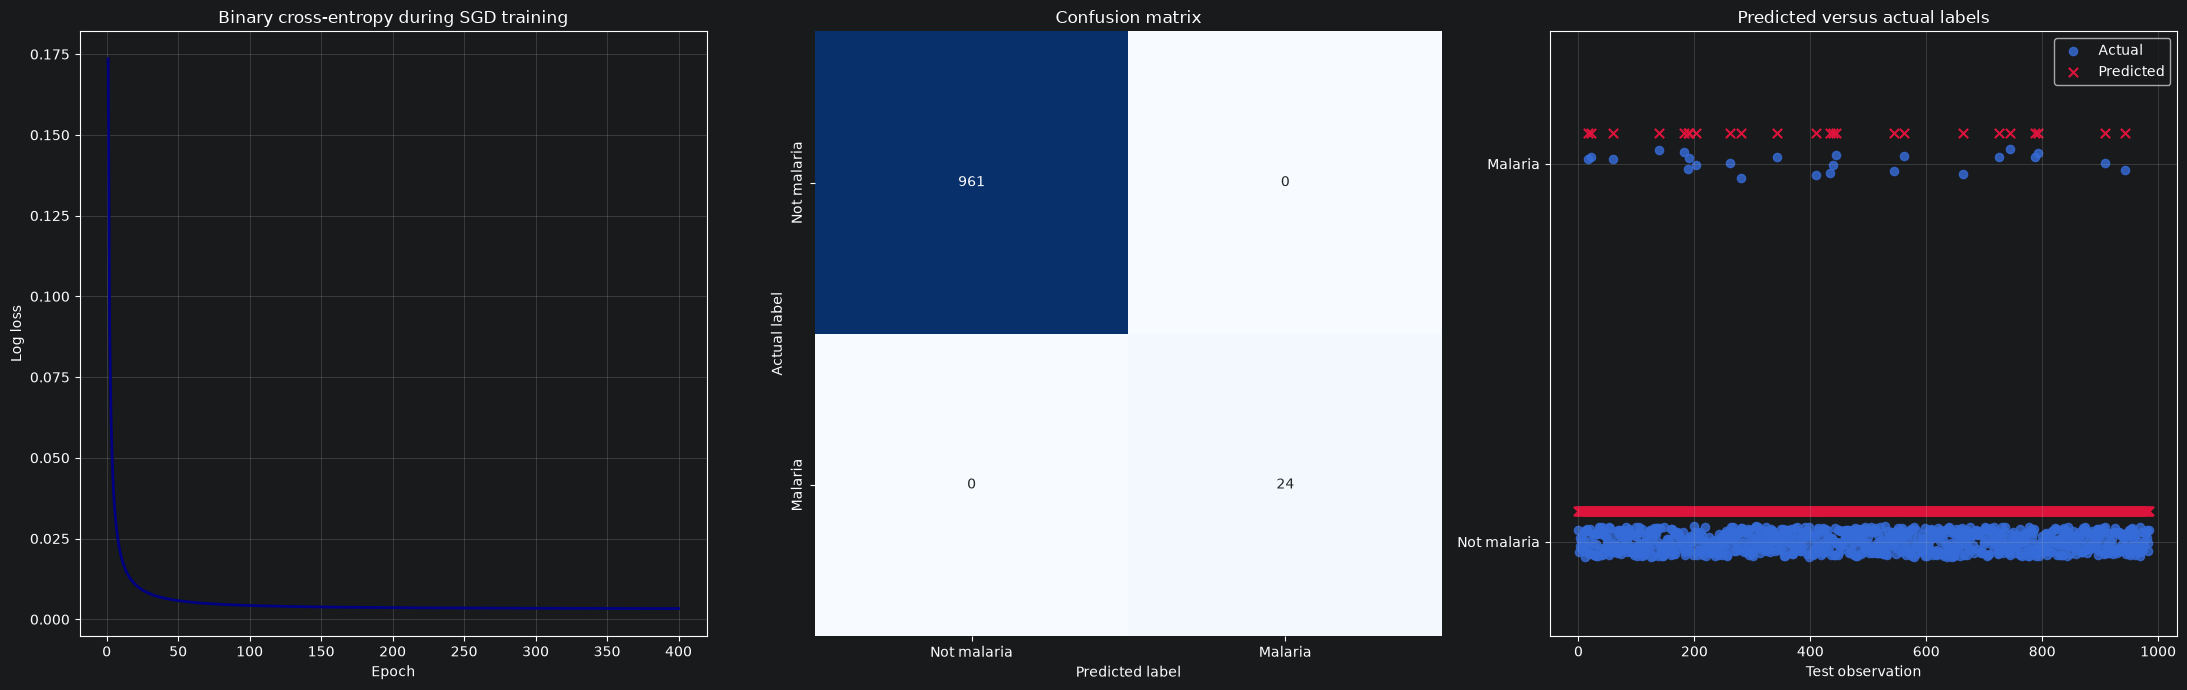

In [9]:
# Plot loss evolution, confusion matrix, and predictions against actual labels.
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

#evolution plot
axes[0].plot(range(1, EPOCHS + 1), loss_history, color="navy", linewidth=2)
axes[0].set_title("Binary cross-entropy during SGD training")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Log loss")
axes[0].grid(alpha=0.3)

#confusion matrix
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1],
    xticklabels=["Not malaria", "Malaria"],
    yticklabels=["Not malaria", "Malaria"]
)
axes[1].set_title("Confusion matrix")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("Actual label")

#predictions versus actual labels
test_order = np.arange(len(y_test))
axes[2].scatter(test_order, y_test + np.random.default_rng(RANDOM_STATE).uniform(-0.04, 0.04, len(y_test)),
                label="Actual", alpha=0.8, s=35)
axes[2].scatter(test_order, y_pred + 0.08, marker="x", color="crimson",
                label="Predicted", s=45)
axes[2].set_title("Predicted versus actual labels")
axes[2].set_xlabel("Test observation")
axes[2].set_yticks([0, 1], ["Not malaria", "Malaria"])
axes[2].set_ylim(-0.25, 1.35)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()